# Process Monitoring and Discrepancy Analysis in the Tennessee Eastman Process using Statistical Metrics

In [102]:
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
import pyreadr
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

current_dir = Path(os.getcwd())
base_data_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "archive"
save_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "processed_csv"
save_path.mkdir(parents=True, exist_ok=True)

In [103]:
files_to_load = {
    "fault_free_test": "TEP_FaultFree_Testing.RData",
    "fault_free_train": "TEP_FaultFree_Training.RData",
    "faulty_test": "TEP_Faulty_Testing.RData",
    "faulty_train": "TEP_Faulty_Training.RData"
}


dfs = {}

for key, filename in files_to_load.items():
    csv_path = save_path / f"{key}.csv"
    
    if csv_path.exists():
        try:
            print(f"CSV file {key}.csv exists. Loading from CSV.")
            dfs[key] = pd.read_csv(csv_path)
            continue 
        except Exception as e:
            print(f"Warning: Failed to load {key}.csv ({e}). Proceeding to load from RData.")

    file_path = base_data_path / filename
    if file_path.exists():
        print(f"Loading {filename} (RData) in progress...")
        r_data = pyreadr.read_r(file_path)
        object_name = list(r_data.keys())[0]
        dfs[key] = r_data[object_name]
        
        dfs[key].to_csv(csv_path, index=False)
        print(f"File {filename} successfully converted and saved as CSV.")
    else:
        print(f"Error: Source file {filename} not found in {base_data_path}")



CSV file fault_free_test.csv exists. Loading from CSV.
CSV file fault_free_train.csv exists. Loading from CSV.
CSV file faulty_test.csv exists. Loading from CSV.
CSV file faulty_train.csv exists. Loading from CSV.


In [104]:
df_faulty_test = dfs["faulty_test"]
df_faulty_train = dfs["faulty_train"]
df_fault_free_test = dfs["fault_free_test"]
df_fault_free_train = dfs["fault_free_train"]

## Methodological Framework and Comparison Techniques

To rigorously analyze and monitor process deviations, structural anomalies, and temporal drifts within the Tennessee Eastman Process (TEP), the framework implements a combination of statistical distribution comparisons, multi-variable sensitivity rankings, and temporal tracking techniques:

1. **Global Distributional Discrepancy Metrics**:
   * **Maximum Mean Discrepancy (MMD)**: A kernel two-sample test utilizing the Radial Basis Function (RBF) kernel to evaluate the overall divergence between a reference state and a target condition in a reproducing kernel Hilbert space (RKHS).
   * **Wasserstein Distance ($1$-Wasserstein / Earth Mover's Distance)**: Computed across individual process features to measure the minimal cost of transforming one marginal distribution into another, offering direct physical interpretability of univariate shifts.
   * **Mahalanobis Distance**: A multivariate distance metric that accounts for linear correlations and covariance structures inherent in the TEP process variables, stabilized via diagonal regularization to avoid numerical singularities.

2. **Variable Sensitivity and Ranking via Visual Analytics**:
   * **Sorted Vertical Heatmaps**: Displays the top-ranked process variables driving the anomaly, sorted by their individual Wasserstein distance values and mapped onto a high-contrast diverging colormap (`crest`) to immediately highlight critical deviations.

3. **Temporal Dynamics Tracking via Sliding-Window Analysis**:
   * **Rapid Sliding-Window Framework**: Inspects how discrepancies evolve chronologically across specific simulation runs by calculating rolling window distances over key process variables, allowing for the precise tracking of transient behaviors and failure propagation over time.

In [105]:
# 1. Supporting Functions
def compute_mmd(X, Y, gamma=0.1):
    """Computes Maximum Mean Discrepancy (MMD) with RBF kernel."""
    if len(X) > 5000: X = X[np.random.choice(X.shape[0], 5000, replace=False)]
    if len(Y) > 5000: Y = Y[np.random.choice(Y.shape[0], 5000, replace=False)]
    
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    return float(XX.mean() + YY.mean() - 2 * XY.mean())

def compute_mahalanobis_distance(df_source, df_target, features):
    """Computes average Mahalanobis distance between target and source distribution."""
    source_data = df_source[features].values
    target_data = df_target[features].values
    
    mean_vec = np.mean(source_data, axis=0)
    cov_matrix = np.cov(source_data, rowvar=False)
    
    # Diagonal regularization to prevent numerical singularities due to TEP collinearity
    cov_matrix += np.eye(cov_matrix.shape[0]) * 1e-5
    
    try:
        inv_cov_matrix = np.linalg.inv(cov_matrix)
    except np.linalg.LinAlgError:
        inv_cov_matrix = np.linalg.pinv(cov_matrix) # Pseudoinverse fallback if near-singular
        
    diff = target_data - mean_vec
    left = np.dot(diff, inv_cov_matrix)
    mahal_vals = np.sqrt(np.sum(left * diff, axis=1))
    
    return float(np.mean(mahal_vals))

def calculate_sliding_discrepancy(df_source, df_target, features, window_size=50, step=20, top_k_features=10):
    """
    Versione ultra-veloce dello sliding window:
    - Utilizza solo le top_k_features più rilevanti per la Wasserstein.
    - Rimuove la MMD a finestre (pesante computazionalmente) concentrandosi sulla Wasserstein media.
    """
    scaler = StandardScaler().fit(df_source[features])
    source_scaled = scaler.transform(df_source[features])
    target_scaled = scaler.transform(df_target[features])
    
    # Per velocità, identifichiamo prima le feature che variano di più globalmente
    global_w = [wasserstein_distance(source_scaled[:, i], target_scaled[:, i]) for i in range(len(features))]
    top_indices = np.argsort(global_w)[-top_k_features:]
    
    wasserstein_scores = []
    time_steps = []
    
    # Mappatura dei campioni reali per l'asse X (se presente la colonna 'sample')
    samples_index = df_target['sample'].values if 'sample' in df_target.columns else np.arange(len(df_target))

    # Sliding window ottimizzata
    for start in range(0, len(target_scaled) - window_size, step):
        end = start + window_size
        target_win = target_scaled[start:end, top_indices]
        source_win = source_scaled[start:end, top_indices] if end <= len(source_scaled) else source_scaled[:window_size, top_indices]
        
        # Calcolo Wasserstein solo sulle feature chiave
        dists = [wasserstein_distance(source_win[:, j], target_win[:, j]) for j in range(target_win.shape[1])]
        
        wasserstein_scores.append(np.mean(dists))
        time_steps.append(samples_index[end - 1])
        
    return time_steps, wasserstein_scores

def evaluate_pair(df_source, df_target, features, pair_name, top_n=10, run_id=1.0, injection_sample=160):
    """
    Complete pipeline for a Source-Target pair:
    - Computes global metrics
    - Generates sorted vertical heatmap
    - Generates temporal sliding window on a single simulation run (avoiding concatenation mess)
    """
    if df_source.empty or df_target.empty:
        print(f"Warning: The dataset for '{pair_name}' is empty.")
        return None
        
    # Standardization strictly fitted on the Source
    scaler = StandardScaler().fit(df_source[features])
    s_scaled = scaler.transform(df_source[features])
    t_scaled = scaler.transform(df_target[features])
    
    # 1. Global Metrics
    mmd_val = compute_mmd(s_scaled, t_scaled)
    w_distances = [wasserstein_distance(s_scaled[:, i], t_scaled[:, i]) for i in range(len(features))]
    mahal_val = compute_mahalanobis_distance(df_source, df_target, features)
    
    avg_w = np.mean(w_distances)
    max_w = np.max(w_distances)
    
    print(f"ANALYSIS SCENARIO: {pair_name}")
    print(f"MMD Score (Global):        {mmd_val:.5f}")
    print(f"Wasserstein (Average):     {avg_w:.5f}")
    print(f"Wasserstein (Max Feature): {max_w:.5f}")
    print(f"Mahalanobis (Covariance):  {mahal_val:.2f}")
    
    # --- PLOT: Ordered Vertical Heatmap (Top N Features) con palette 'crest' ---
    df_features_sorted = pd.DataFrame({
        'Feature': features,
        'Wasserstein': w_distances
    }).sort_values(by='Wasserstein', ascending=False).head(top_n).set_index('Feature')
    plt.figure(figsize=(6, max(3, top_n * 0.3)))
    sns.heatmap(df_features_sorted, cmap="crest", annot=True, fmt=".2f", cbar=True,
               cbar_kws={'label': 'Wasserstein Distance'}, linewidths=0.5)
    plt.title(f"Feature Sensitivity (Top {top_n} Sorted): {pair_name}", fontsize=10)
    plt.xlabel("Scenario")
    plt.ylabel("TEP Process Variables")
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    # --- PLOT: Temporal Dynamics on a Single Run (Sliding Window) ---
    if 'simulationRun' in df_target.columns:
        single_target_run = df_target[df_target['simulationRun'] == run_id]
        single_source_run = df_source[df_source['simulationRun'] == run_id] if 'simulationRun' in df_source.columns and not df_source[df_source['simulationRun'] == run_id].empty else df_source
    else:
        single_target_run = df_target
        single_source_run = df_source
        
    if len(single_target_run) > 50:
        steps, w_scores = calculate_sliding_discrepancy(single_source_run, single_target_run, features, window_size=30, step=5, top_k_features=10)
        
        sns.set_theme(style="whitegrid")
        plt.figure(figsize=(10, 4), dpi=120)
        plt.plot(steps, w_scores, color='blue', label='Wasserstein (Top 10 Features Avg)')
        
        # Mostra la linea rossa SOLO se l'injection point ricade all'interno dell'asse X visibile
        if injection_sample is not None and min(steps) <= injection_sample <= max(steps):
            plt.axvline(x=injection_sample, color='red', linestyle='--', label=f'Injection Point (t={injection_sample})')
            
        plt.ylabel('Wasserstein Distance')
        plt.xlabel(f'Sample (Time Step within Run {int(run_id)})')
        plt.title(f'Dynamic Temporal Evolution: {pair_name} (Run {int(run_id)})')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(loc='upper left', fontsize=8)
        plt.tight_layout()
        plt.show()

    return {
        'Scenario': pair_name,
        'MMD': mmd_val,
        'Wasserstein_Avg': avg_w,
        'Mahalanobis': mahal_val
    }

# Initialization of features and results array
features = [c for c in dfs["fault_free_train"].columns if c not in ['faultNumber', 'simulationRun', 'sample']]
all_results = []

## Scenario 1: Point Fault Analysis (Nominal vs. each fault)

### Methodology & Source-Target Selection:
* **Source (`source_base`)**: The baseline nominal operating condition (`fault_free_test`) restricted to simulation run 1. This represents the stable, fault-free chemical process state.
* **Target (`target_subset`)**: Process data from `faulty_test` for **each fault** during simulation run 1.

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_1
MMD Score (Global):        0.00078
Wasserstein (Average):     1.36927
Wasserstein (Max Feature): 13.54585
Mahalanobis (Covariance):  24.70


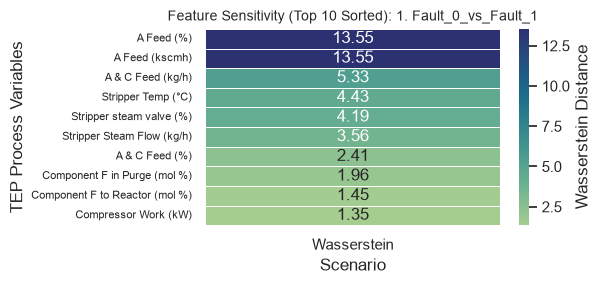

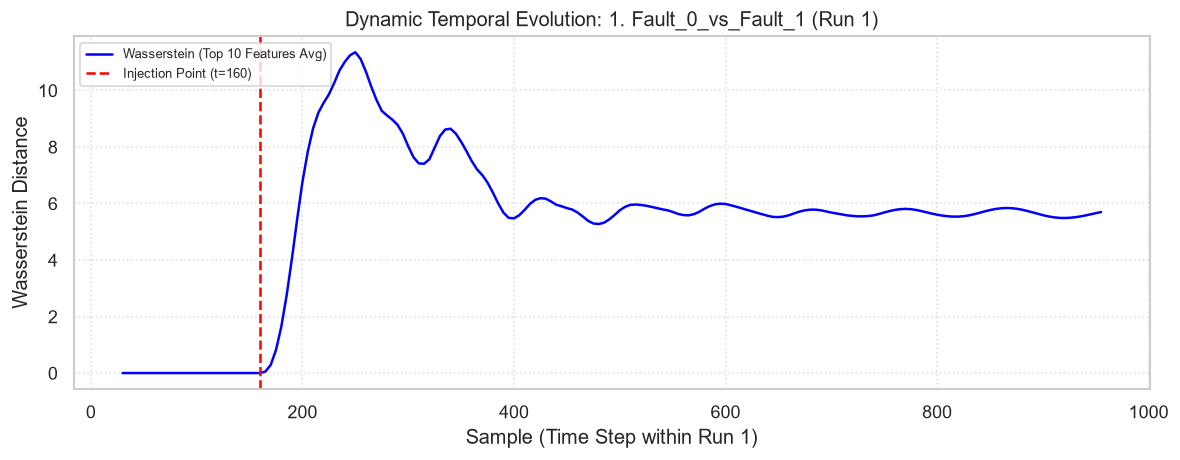

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_2
MMD Score (Global):        0.00082
Wasserstein (Average):     2.85142
Wasserstein (Max Feature): 23.63343
Mahalanobis (Covariance):  49.77


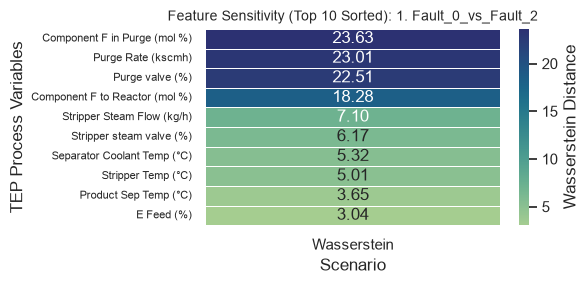

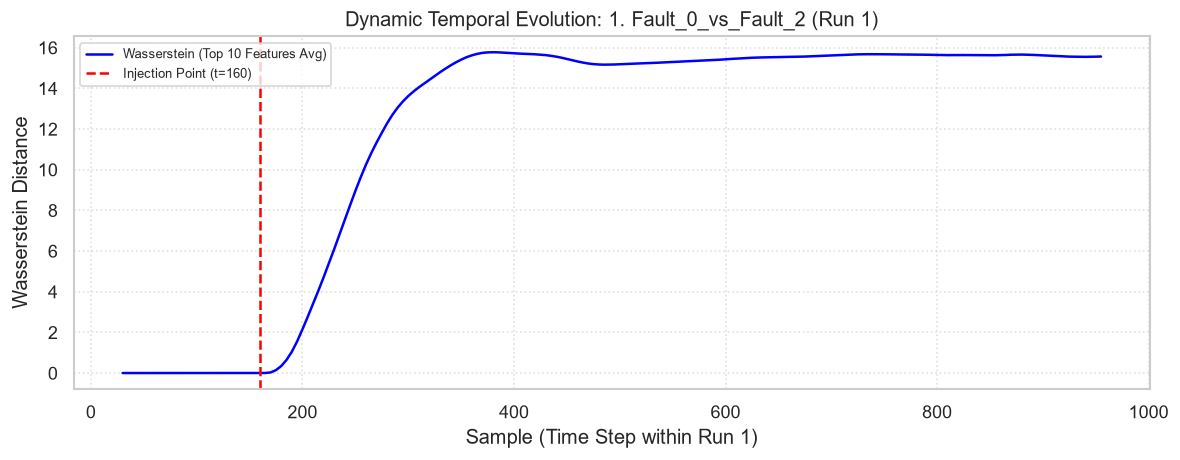

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_3
MMD Score (Global):        0.00040
Wasserstein (Average):     0.01064
Wasserstein (Max Feature): 0.21419
Mahalanobis (Covariance):  6.95


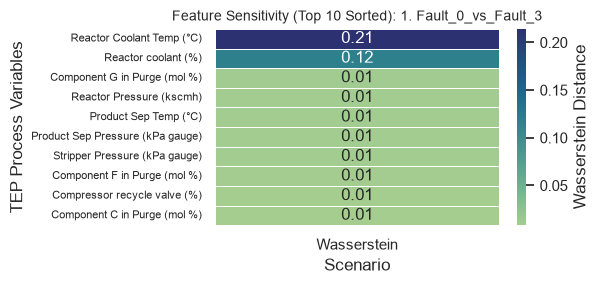

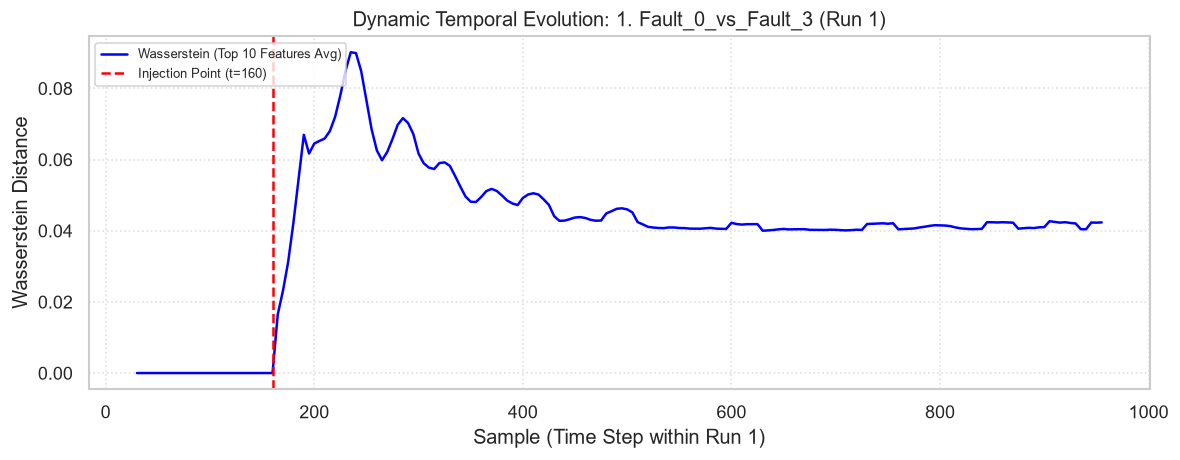

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_4
MMD Score (Global):        0.00099
Wasserstein (Average):     0.11692
Wasserstein (Max Feature): 5.78545
Mahalanobis (Covariance):  11.00


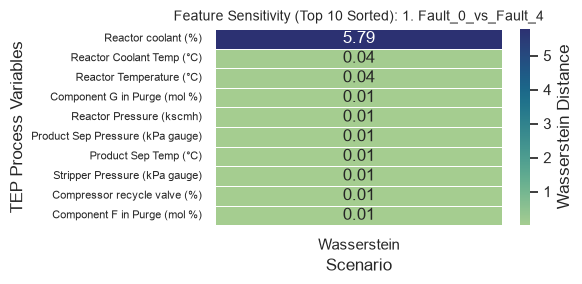

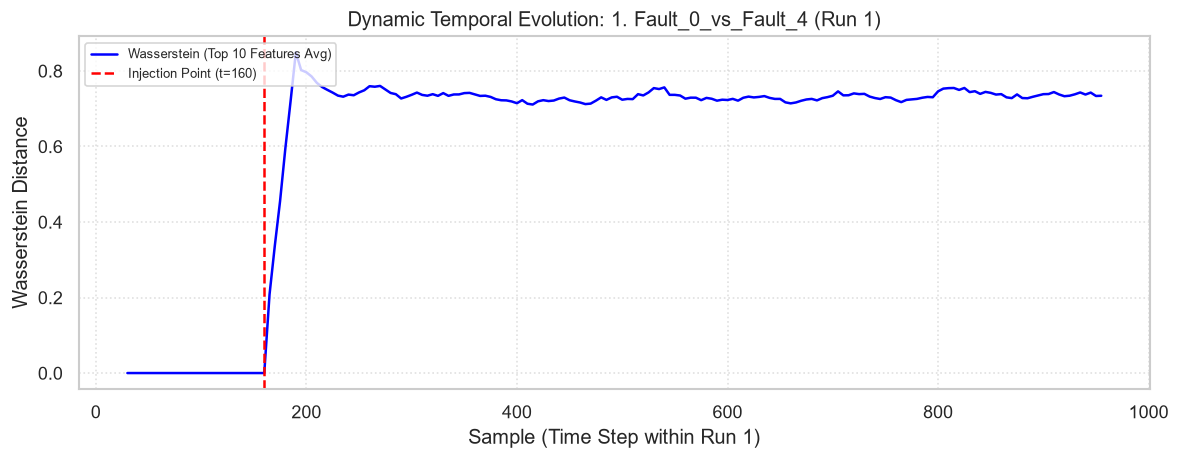

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_5
MMD Score (Global):        0.00052
Wasserstein (Average):     0.26123
Wasserstein (Max Feature): 1.55821
Mahalanobis (Covariance):  92.28


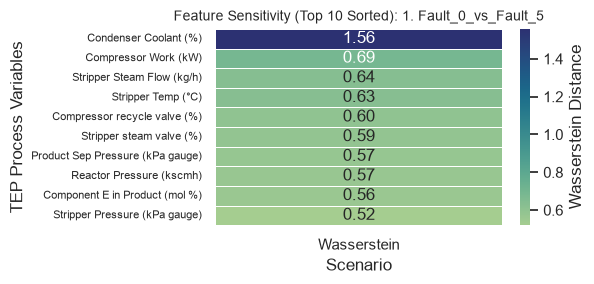

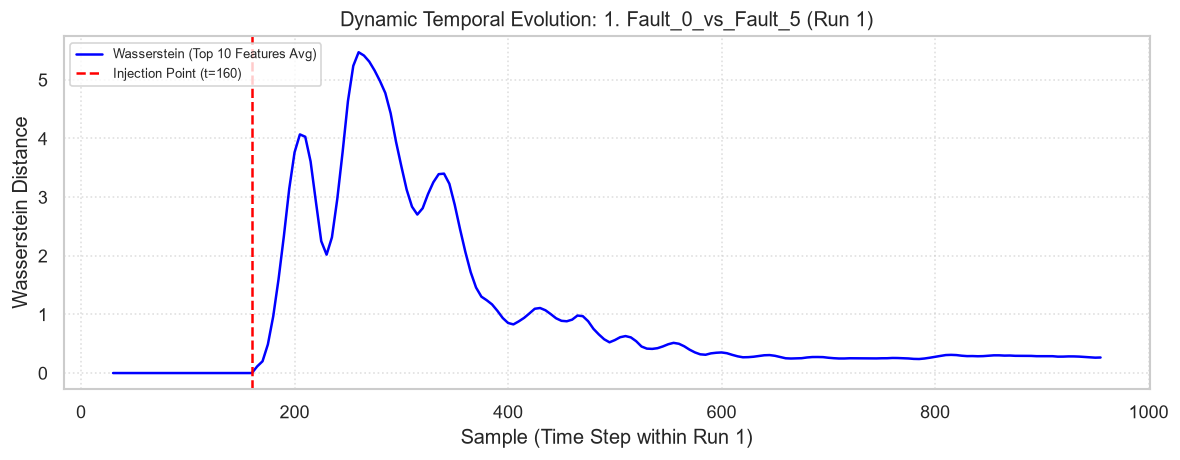

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_6
MMD Score (Global):        0.00070
Wasserstein (Average):     11.00058
Wasserstein (Max Feature): 58.63358
Mahalanobis (Covariance):  921.86


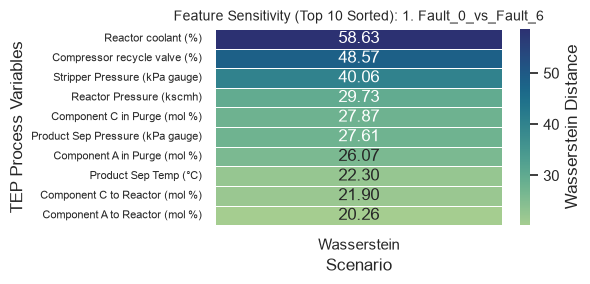

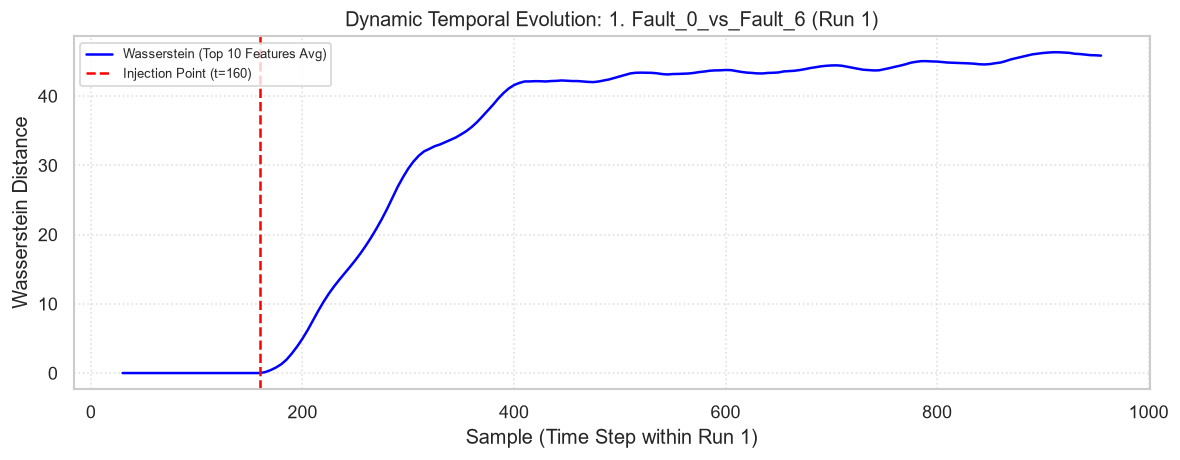

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_7
MMD Score (Global):        0.00076
Wasserstein (Average):     0.79722
Wasserstein (Max Feature): 10.23303
Mahalanobis (Covariance):  16.14


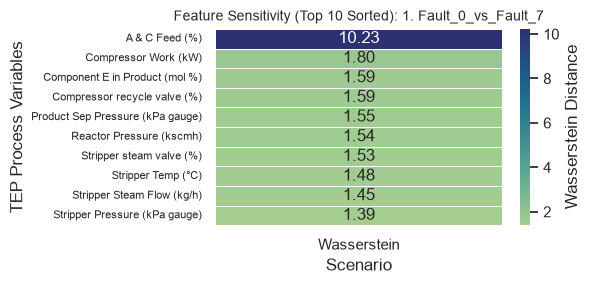

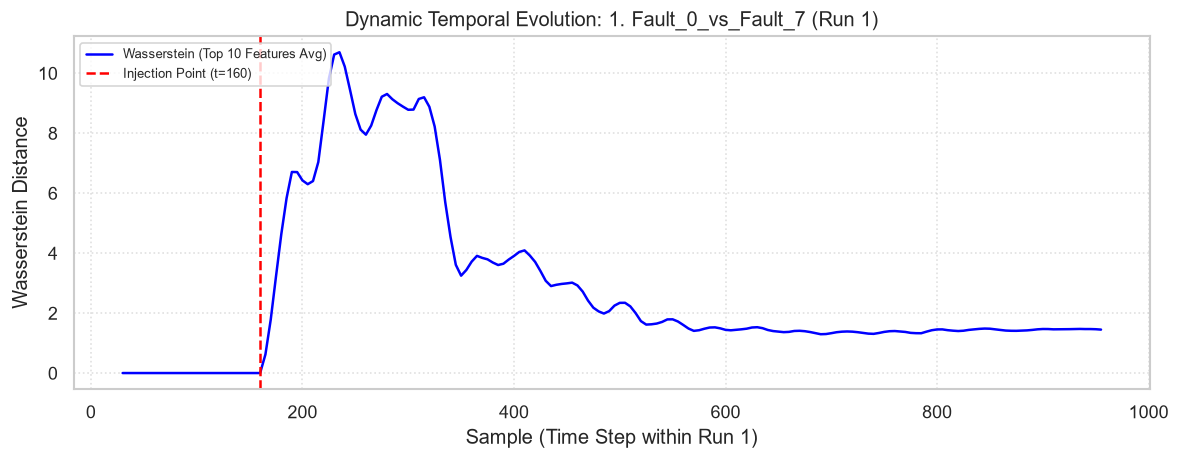

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_8
MMD Score (Global):        0.00069
Wasserstein (Average):     1.84022
Wasserstein (Max Feature): 4.87571
Mahalanobis (Covariance):  22.27


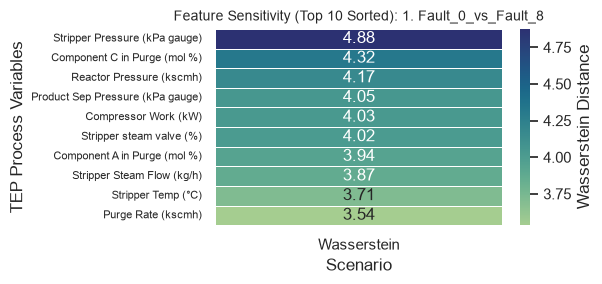

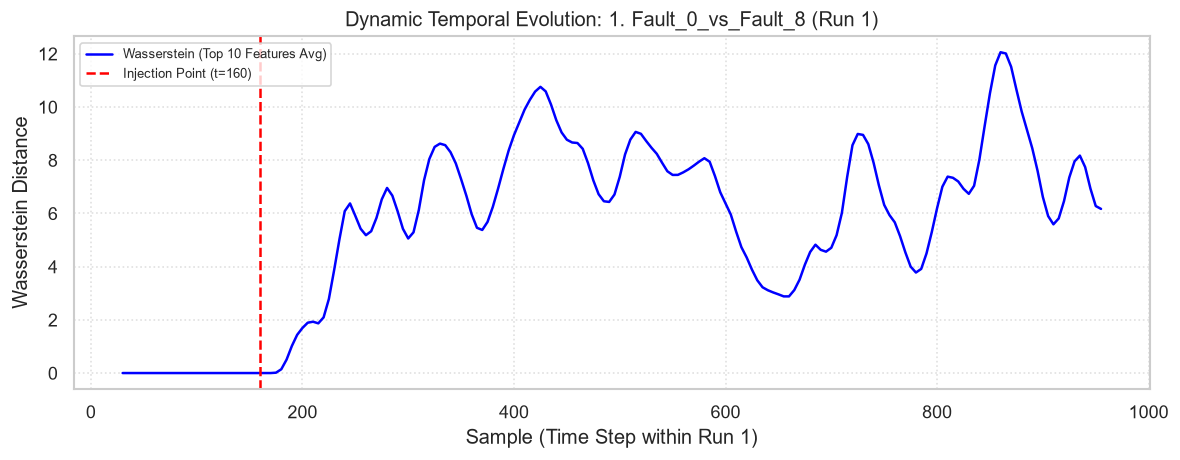

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_9
MMD Score (Global):        0.00040
Wasserstein (Average):     0.00551
Wasserstein (Max Feature): 0.02452
Mahalanobis (Covariance):  6.96


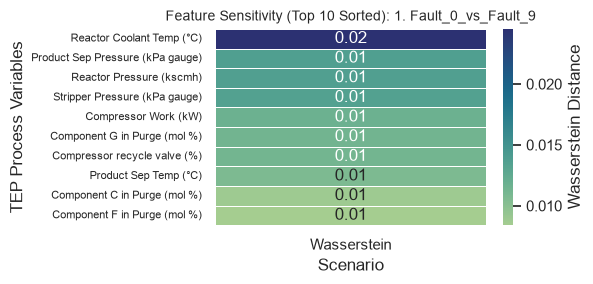

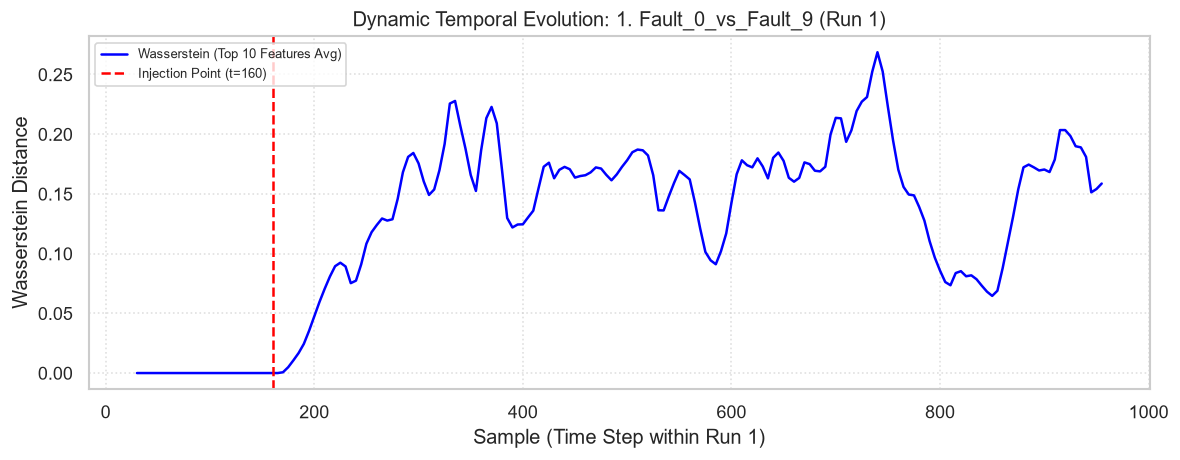

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_10
MMD Score (Global):        0.00056
Wasserstein (Average):     0.16615
Wasserstein (Max Feature): 1.23927
Mahalanobis (Covariance):  15.98


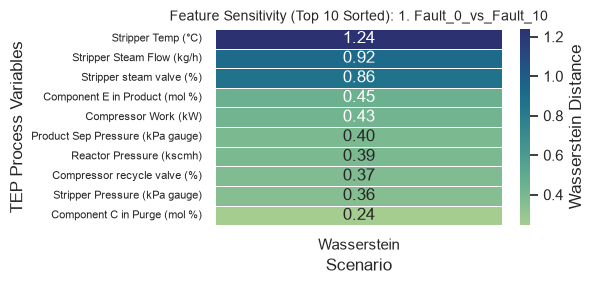

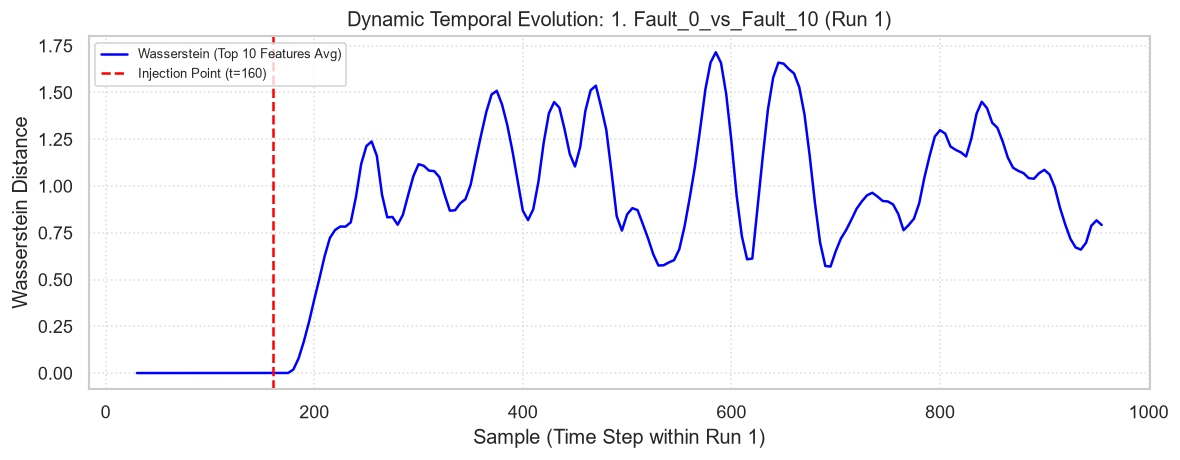

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_11
MMD Score (Global):        0.00062
Wasserstein (Average):     0.12699
Wasserstein (Max Feature): 3.91386
Mahalanobis (Covariance):  10.52


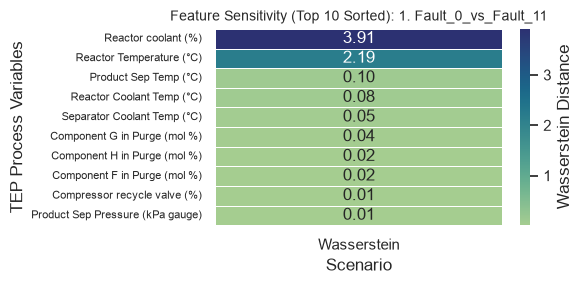

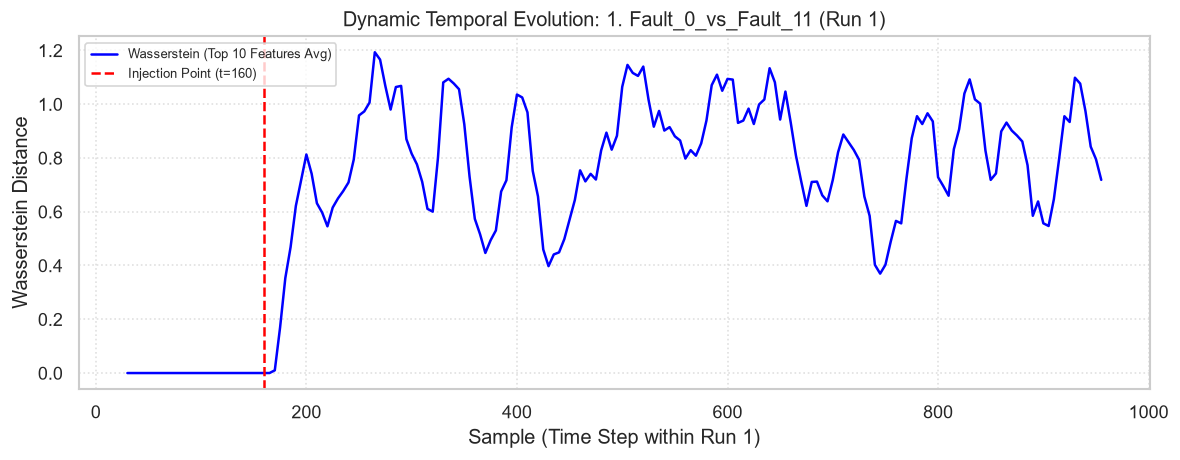

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_12
MMD Score (Global):        0.00068
Wasserstein (Average):     2.99065
Wasserstein (Max Feature): 10.75867
Mahalanobis (Covariance):  95.55


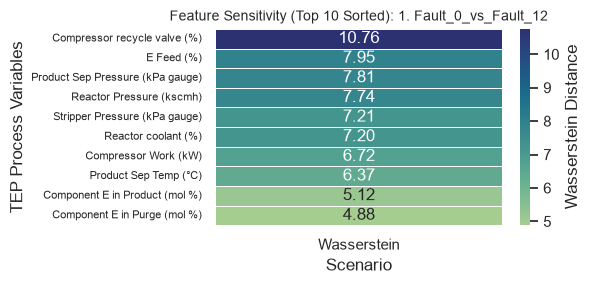

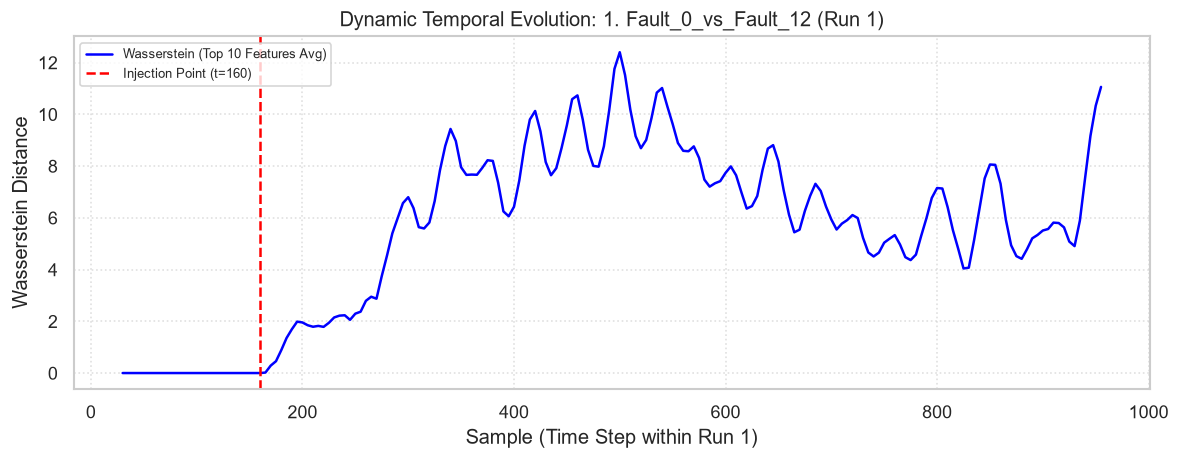

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_13
MMD Score (Global):        0.00068
Wasserstein (Average):     2.38098
Wasserstein (Max Feature): 8.60310
Mahalanobis (Covariance):  58.23


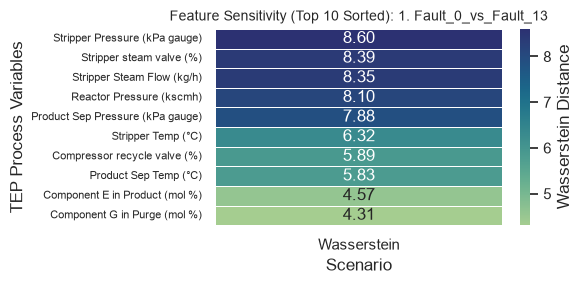

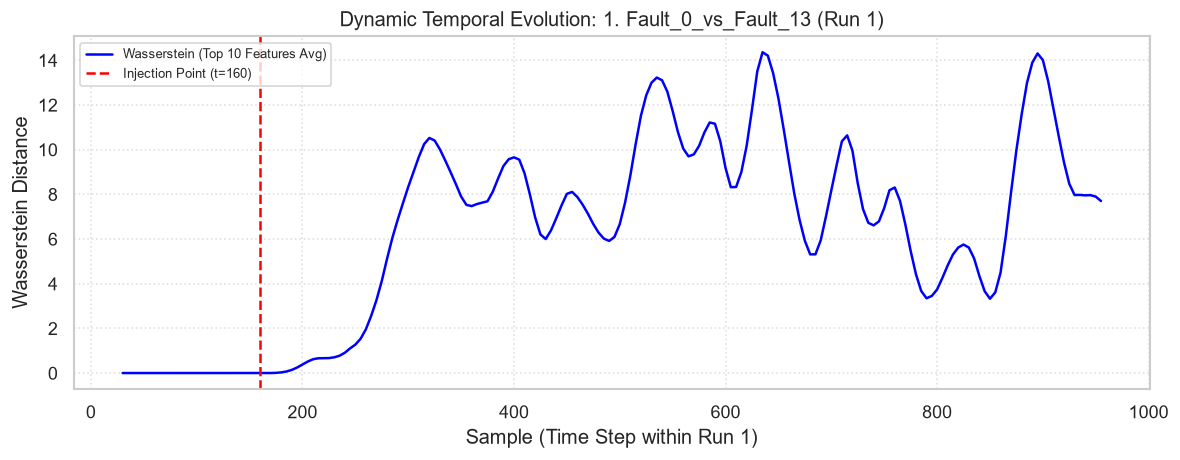

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_14
MMD Score (Global):        0.00071
Wasserstein (Average):     0.50976
Wasserstein (Max Feature): 9.60408
Mahalanobis (Covariance):  22.05


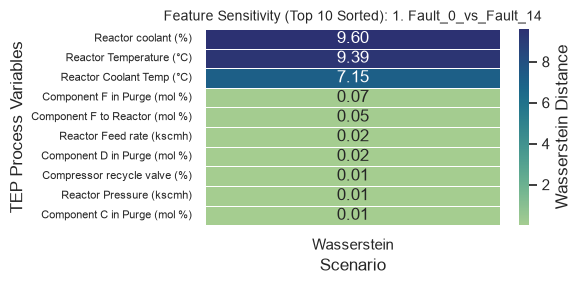

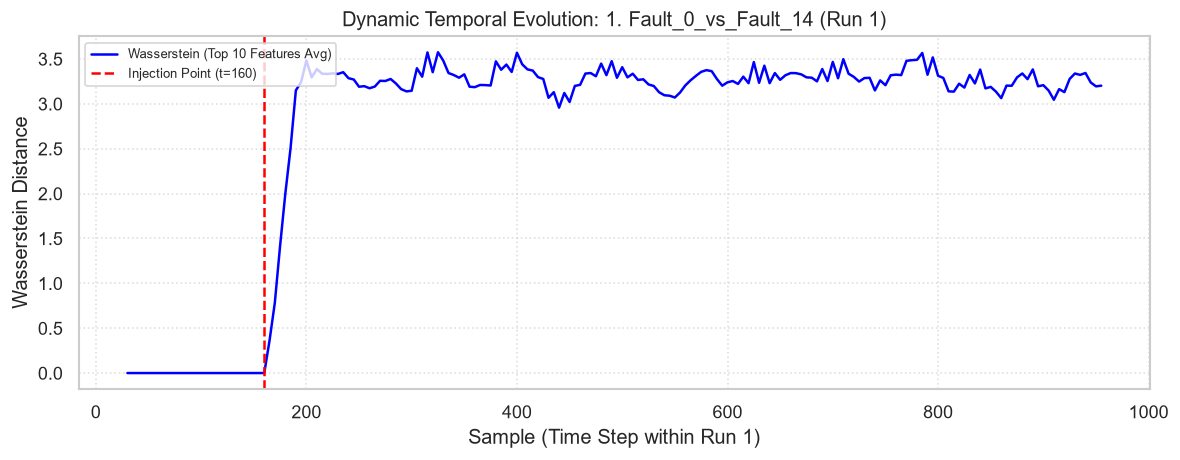

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_15
MMD Score (Global):        0.00040
Wasserstein (Average):     0.00861
Wasserstein (Max Feature): 0.05887
Mahalanobis (Covariance):  7.04


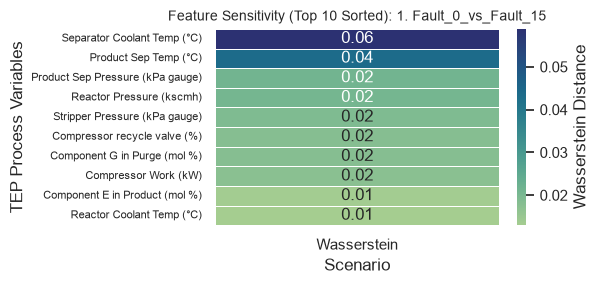

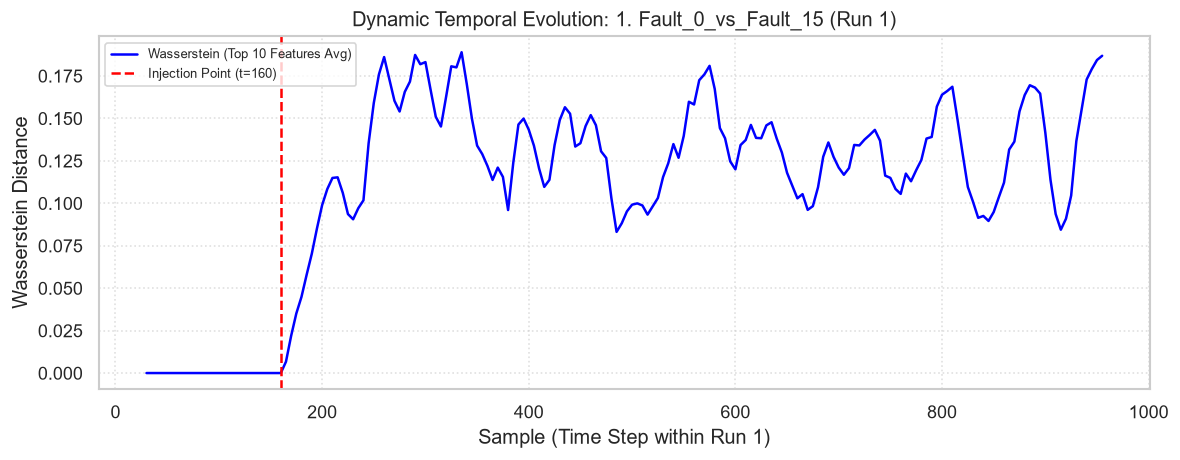

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_16
MMD Score (Global):        0.00050
Wasserstein (Average):     0.08398
Wasserstein (Max Feature): 0.81364
Mahalanobis (Covariance):  17.15


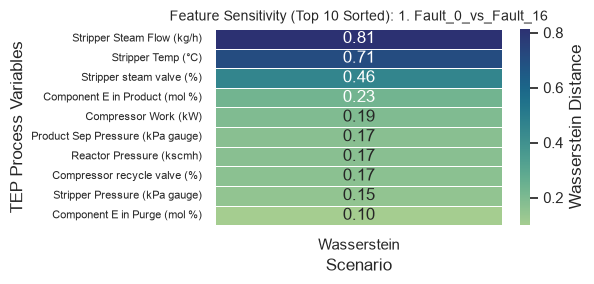

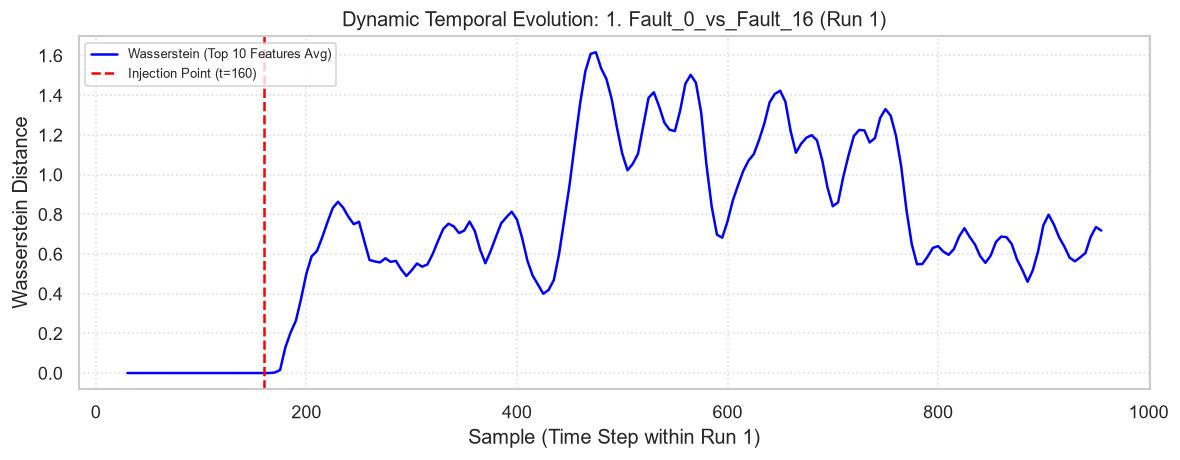

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_17
MMD Score (Global):        0.00067
Wasserstein (Average):     0.66943
Wasserstein (Max Feature): 23.96548
Mahalanobis (Covariance):  43.46


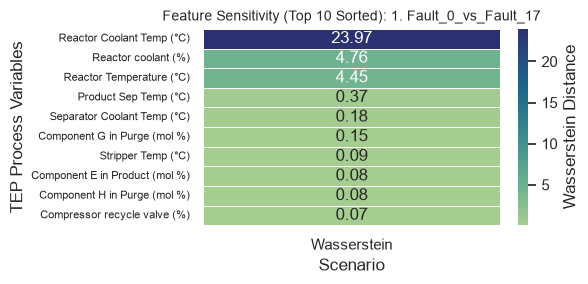

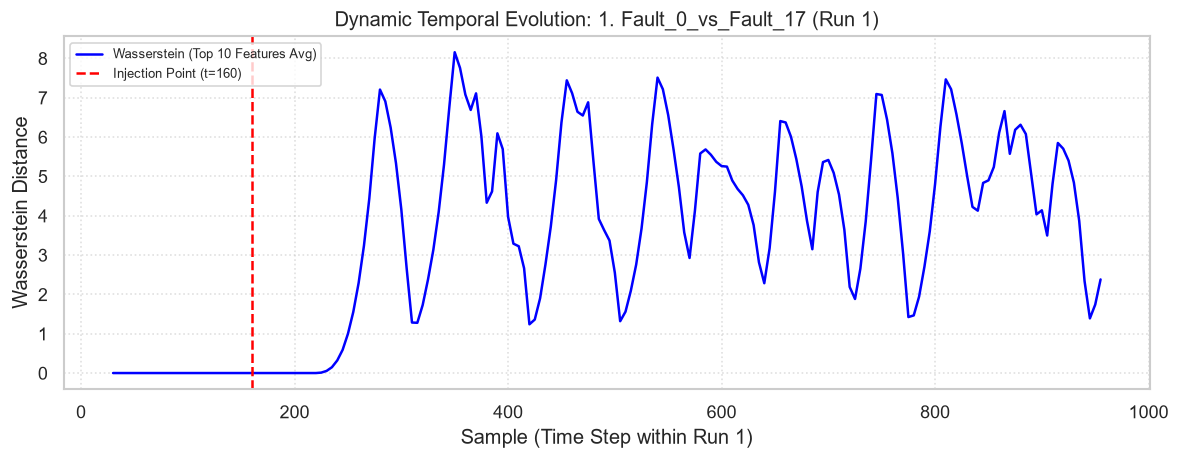

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_18
MMD Score (Global):        0.00066
Wasserstein (Average):     8.81583
Wasserstein (Max Feature): 46.84271
Mahalanobis (Covariance):  509.94


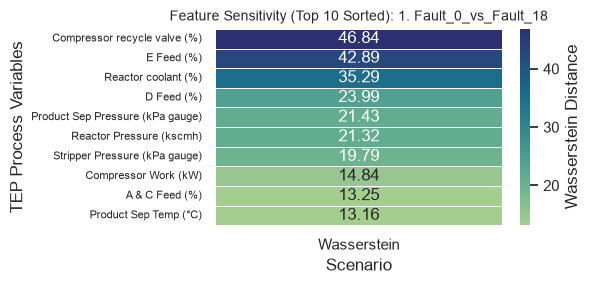

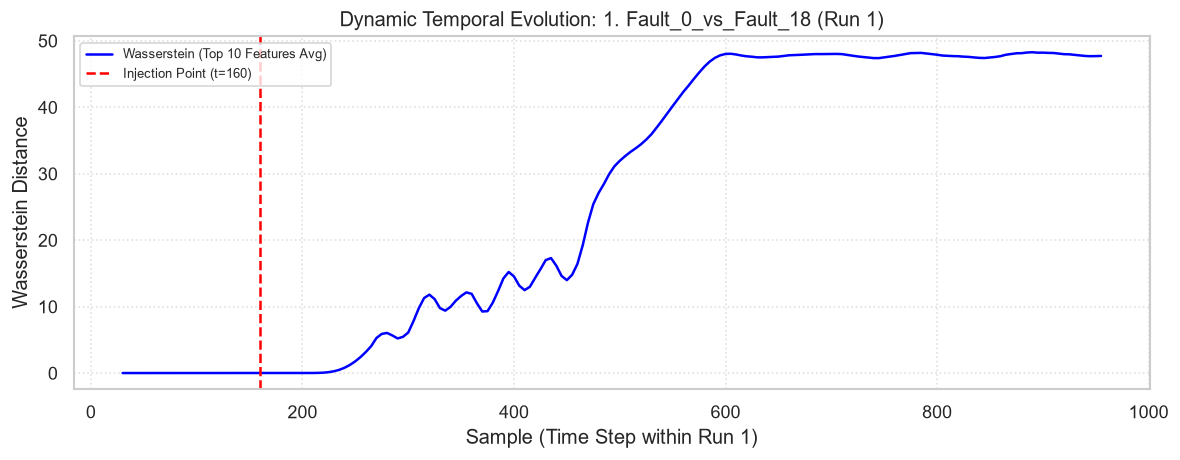

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_19
MMD Score (Global):        0.00050
Wasserstein (Average):     0.05310
Wasserstein (Max Feature): 1.11068
Mahalanobis (Covariance):  11.54


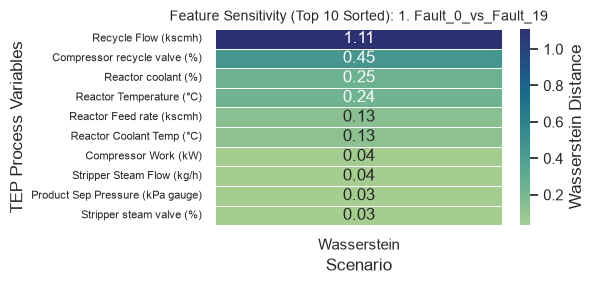

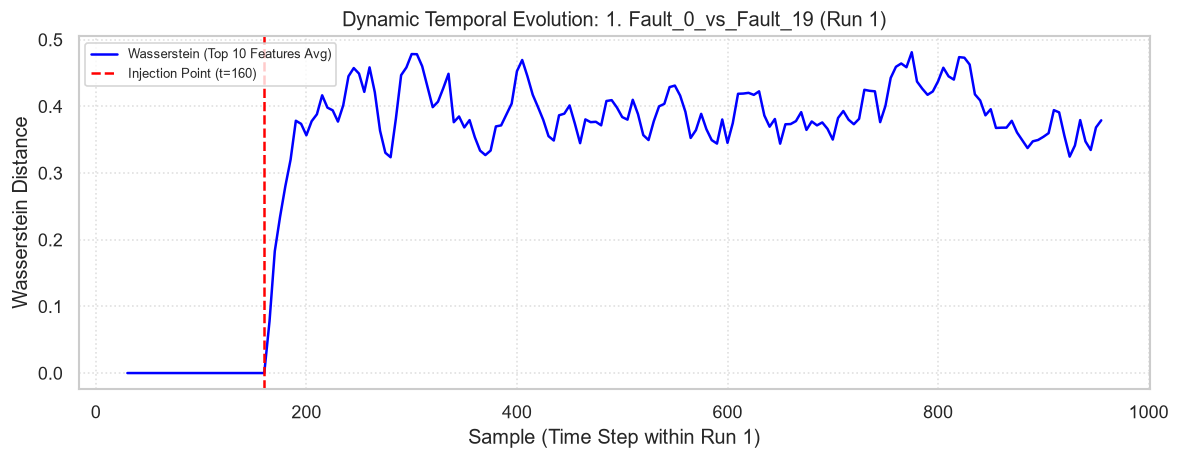

ANALYSIS SCENARIO: 1. Fault_0_vs_Fault_20
MMD Score (Global):        0.00057
Wasserstein (Average):     0.21286
Wasserstein (Max Feature): 3.56134
Mahalanobis (Covariance):  30.41


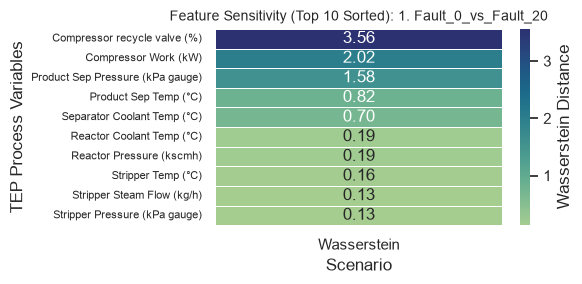

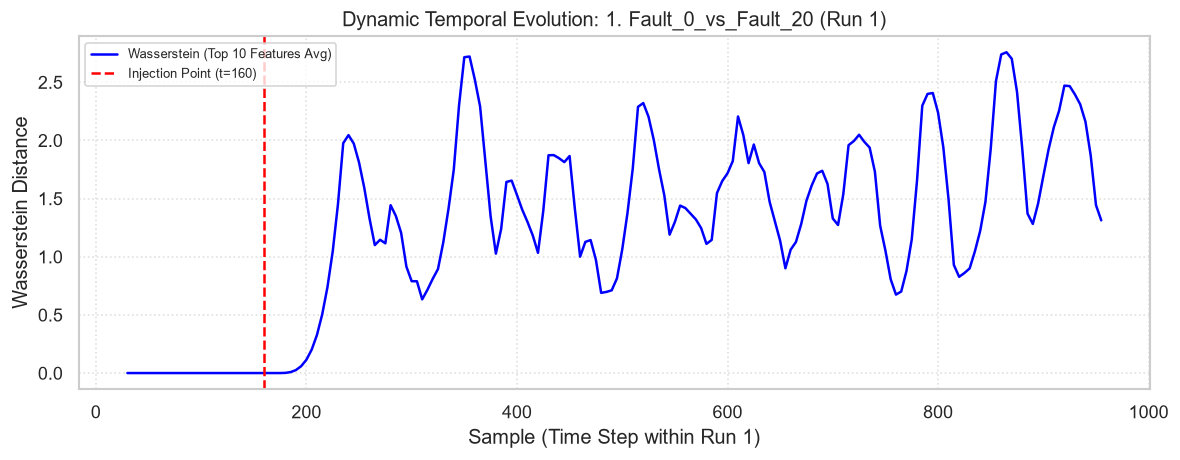

In [106]:
source = dfs["fault_free_test"]

for f_id in range(1, 21):
    target = dfs["faulty_test"][dfs["faulty_test"]['faultNumber'] == f_id]
    res = evaluate_pair(source, target, features, pair_name=f"1. Fault_0_vs_Fault_{f_id}")
    if res: all_results.append(res)

## Scenario 2: Temporal Drift Analysis (Fault 1,2,6,18 Evolution)

### Methodology & Source-Target Selection:
* **Source (`source`)**: The early manifestation phase of each analyzed fault within run 1, captured immediately after injection (samples $160 \le t \le 200$).
* **Target (`target`)**: The extended trajectory of the same fault run from injection onward ($t \ge 160$).



Fault 1 temporal evolution analysis:

ANALYSIS SCENARIO: 2. Temporal Drift (Fault 1 Evolution)
MMD Score (Global):        0.03119
Wasserstein (Average):     1.24758
Wasserstein (Max Feature): 8.75492
Mahalanobis (Covariance):  418.31


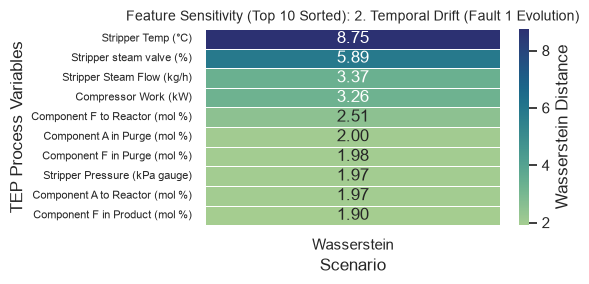

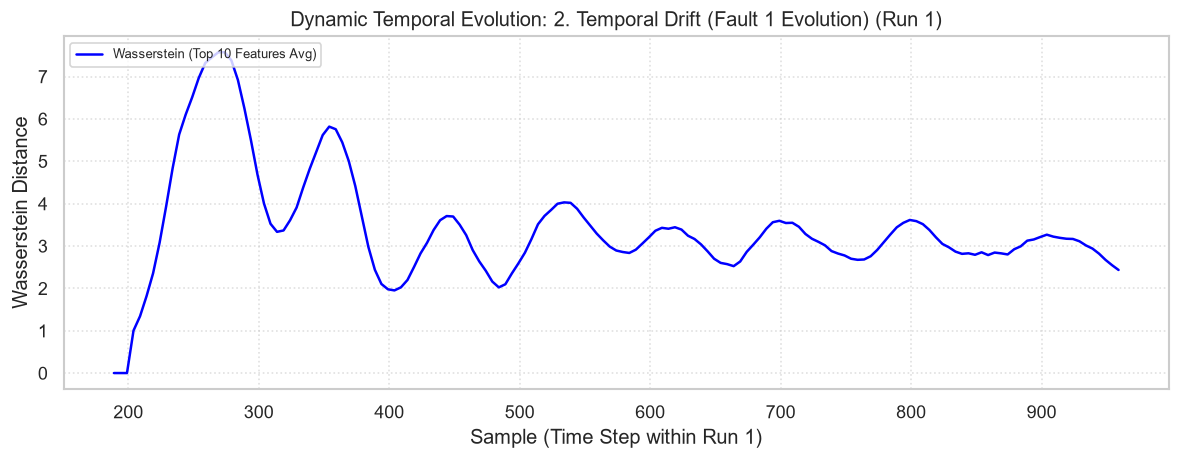


Fault 2 temporal evolution analysis:

ANALYSIS SCENARIO: 2. Temporal Drift (Fault 2 Evolution)
MMD Score (Global):        0.02535
Wasserstein (Average):     3.30574
Wasserstein (Max Feature): 25.32315
Mahalanobis (Covariance):  662.90


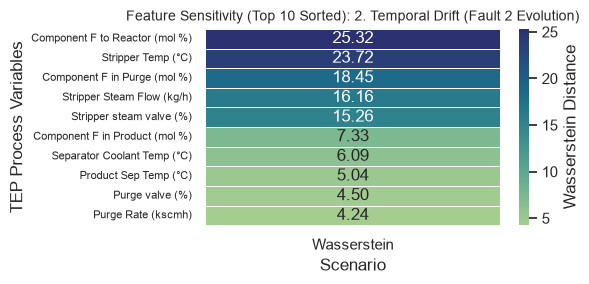

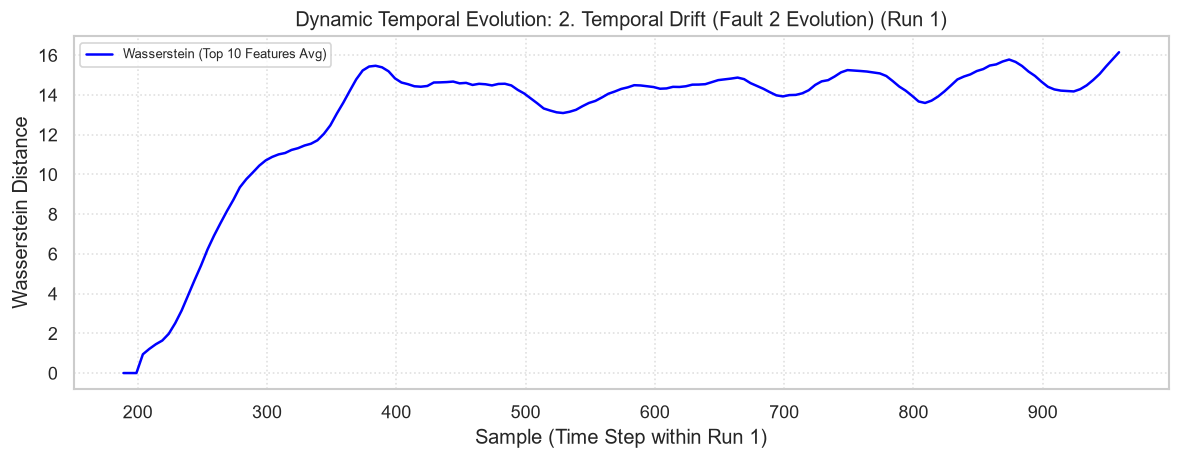


Fault 6 temporal evolution analysis:

ANALYSIS SCENARIO: 2. Temporal Drift (Fault 6 Evolution)
MMD Score (Global):        0.03110
Wasserstein (Average):     7.13288
Wasserstein (Max Feature): 83.53655
Mahalanobis (Covariance):  4536.41


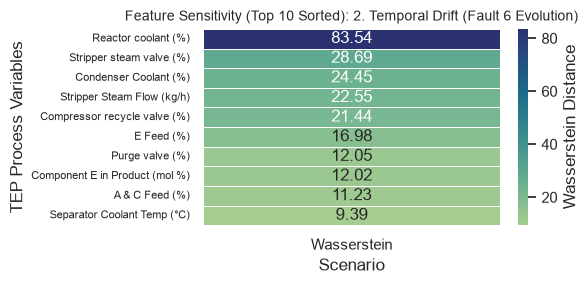

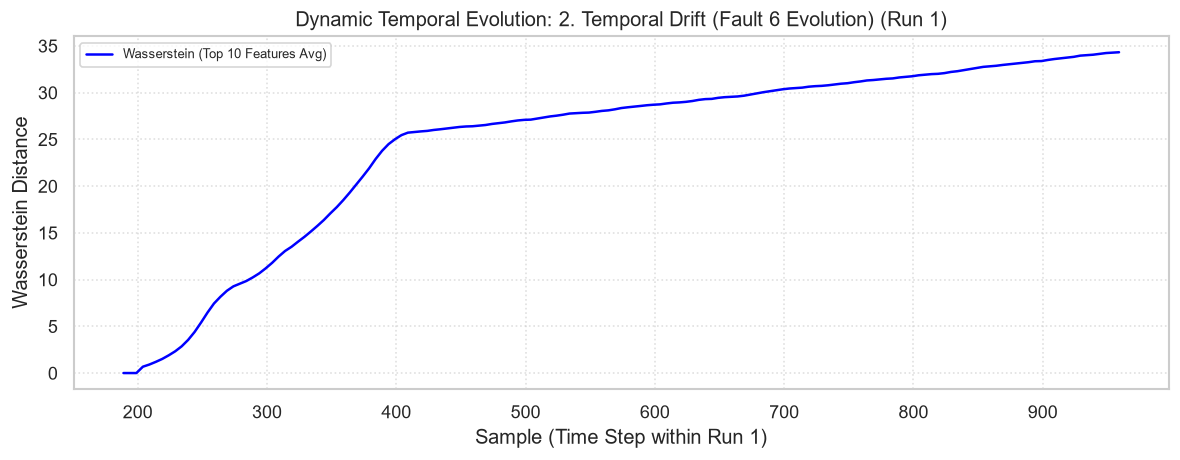


Fault 18 temporal evolution analysis:

ANALYSIS SCENARIO: 2. Temporal Drift (Fault 18 Evolution)
MMD Score (Global):        0.02737
Wasserstein (Average):     14.47647
Wasserstein (Max Feature): 58.98586
Mahalanobis (Covariance):  2715.52


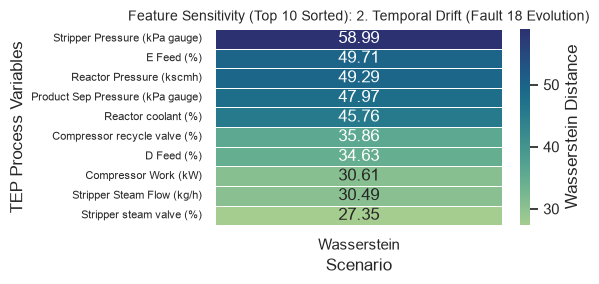

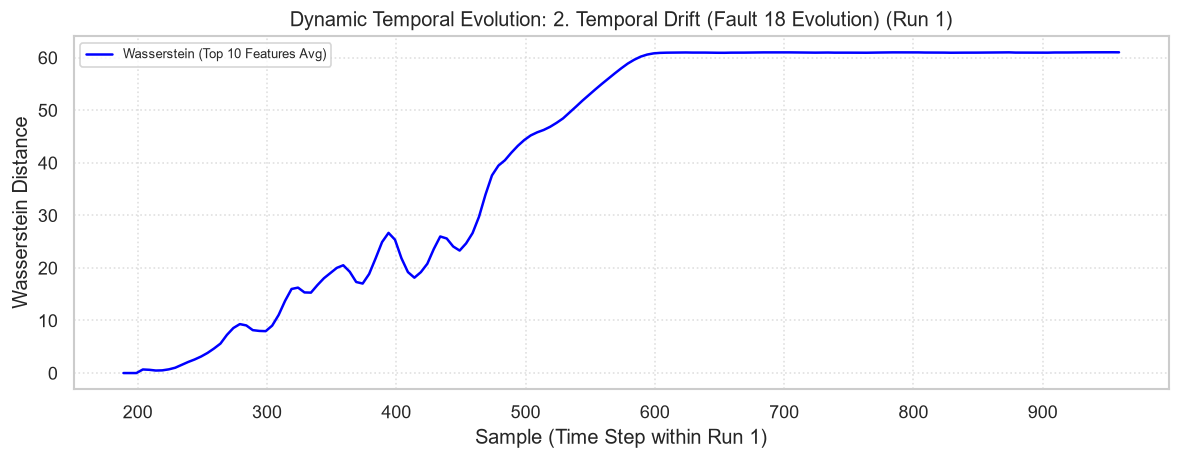

In [107]:
faults = [1,2,6,18]

for i in faults:
    print(f"\nFault {i} temporal evolution analysis:\n")
    fault_i_run1 = df_faulty_test[(df_faulty_test['faultNumber'] == i) & (df_faulty_test['simulationRun'] == 1.0)]
    
    source = fault_i_run1[(fault_i_run1['sample'] >= 160) & (fault_i_run1['sample'] <= 200)]
    target = fault_i_run1[fault_i_run1['sample'] >= 160]
    
    res2 = evaluate_pair(
        df_source=source, 
        df_target=target, 
        features=features, 
        pair_name=f"2. Temporal Drift (Fault {i} Evolution)", 
        top_n=10, 
        run_id=1.0, 
        injection_sample=160, 
    )
    if res2: all_results.append(res2)


## Scenario 3: Pre-Fault vs. Post-Fault Dynamic Transition

### Methodology & Source-Target Selection:
To evaluate the immediate structural impact and the dynamic response of the system to different types of disturbances (e.g., Faults 1, 2, 6, 18), this scenario isolates the transition boundary within a single simulation run:
* **Source (`source`)**: The healthy, steady-state operational window immediately preceding the fault injection (e.g., samples $100 \le t < 160$).
* **Target (`target`)**: The disturbed process trajectory following the fault injection ($t \ge 160$).



Fault 1 pre vs post-fault analysis:

ANALYSIS SCENARIO: 3. Pre vs Post-Fault (Fault 1)
MMD Score (Global):        0.01967
Wasserstein (Average):     1.74620
Wasserstein (Max Feature): 14.56655
Mahalanobis (Covariance):  111.32


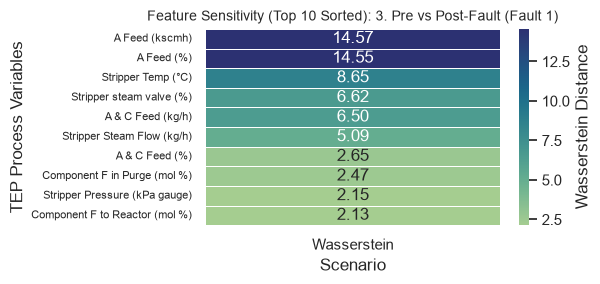

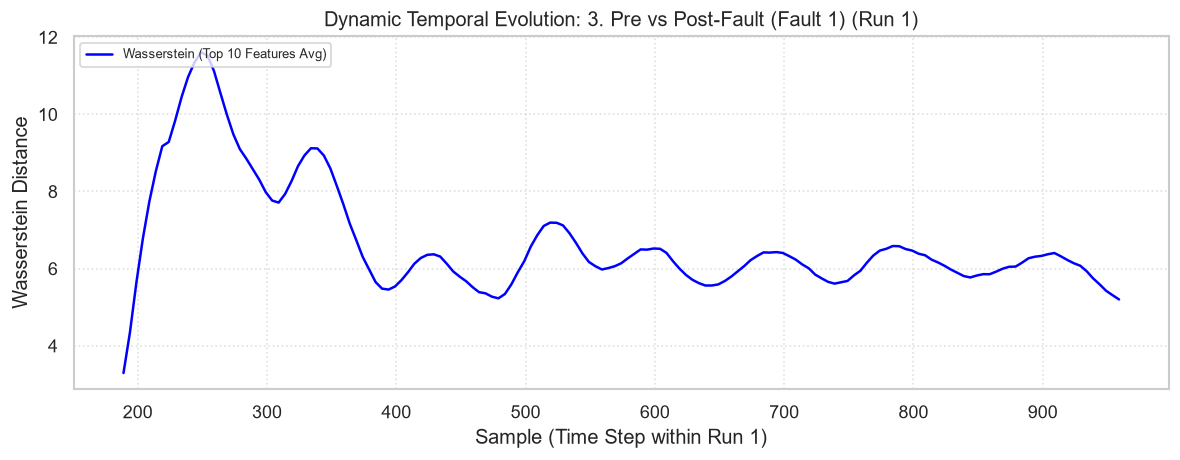


Fault 2 pre vs post-fault analysis:

ANALYSIS SCENARIO: 3. Pre vs Post-Fault (Fault 2)
MMD Score (Global):        0.01979
Wasserstein (Average):     3.62312
Wasserstein (Max Feature): 27.45871
Mahalanobis (Covariance):  217.17


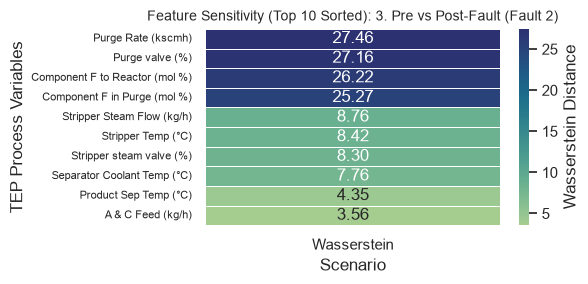

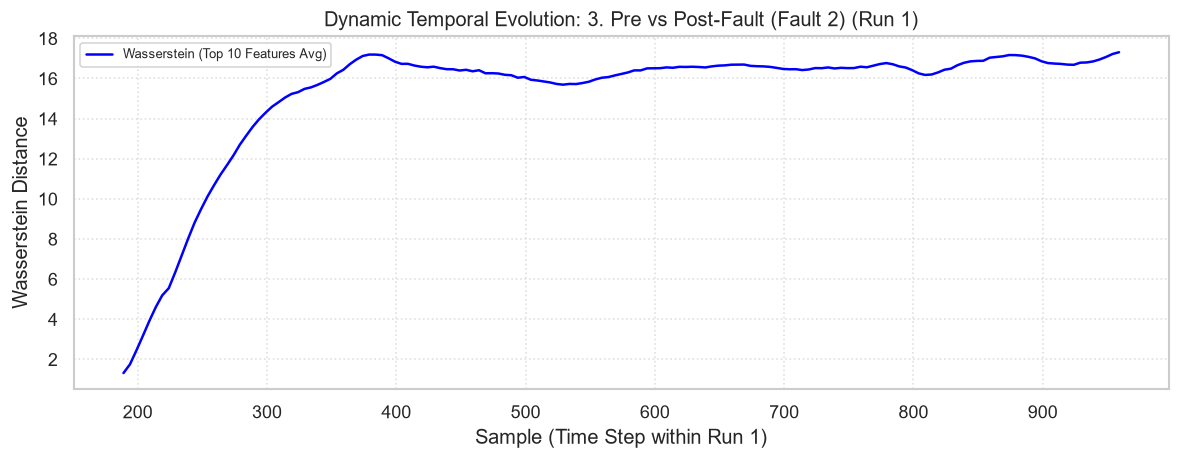


Fault 6 pre vs post-fault analysis:

ANALYSIS SCENARIO: 3. Pre vs Post-Fault (Fault 6)
MMD Score (Global):        0.02160
Wasserstein (Average):     12.41358
Wasserstein (Max Feature): 85.76609
Mahalanobis (Covariance):  4112.14


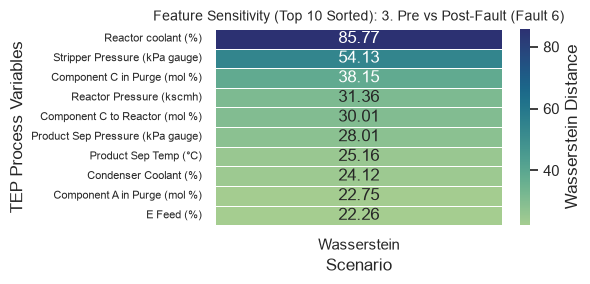

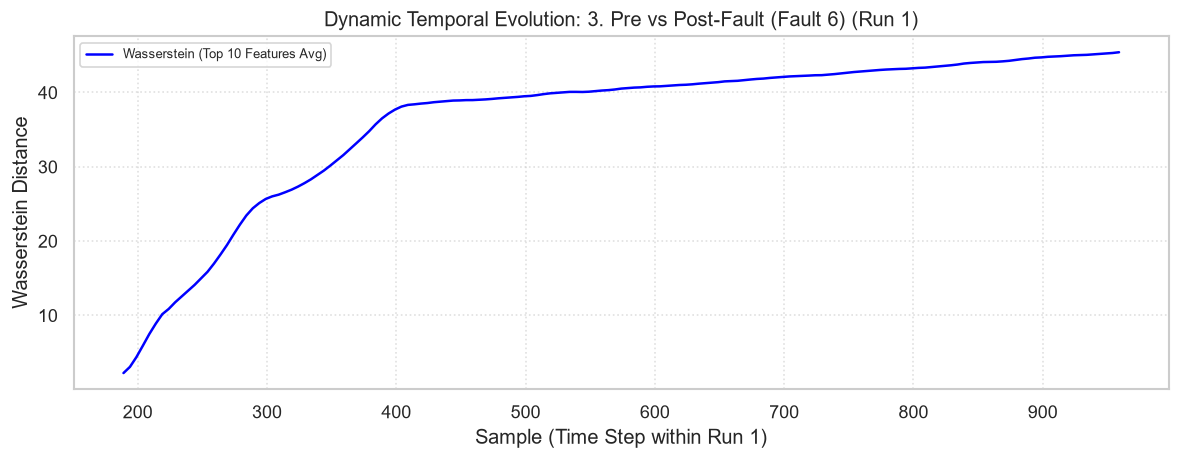


Fault 18 pre vs post-fault analysis:

ANALYSIS SCENARIO: 3. Pre vs Post-Fault (Fault 18)
MMD Score (Global):        0.03033
Wasserstein (Average):     10.77793
Wasserstein (Max Feature): 57.85904
Mahalanobis (Covariance):  1222.61


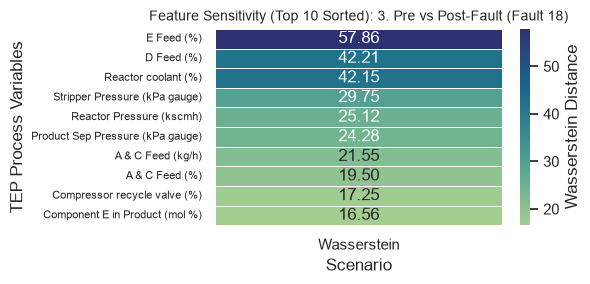

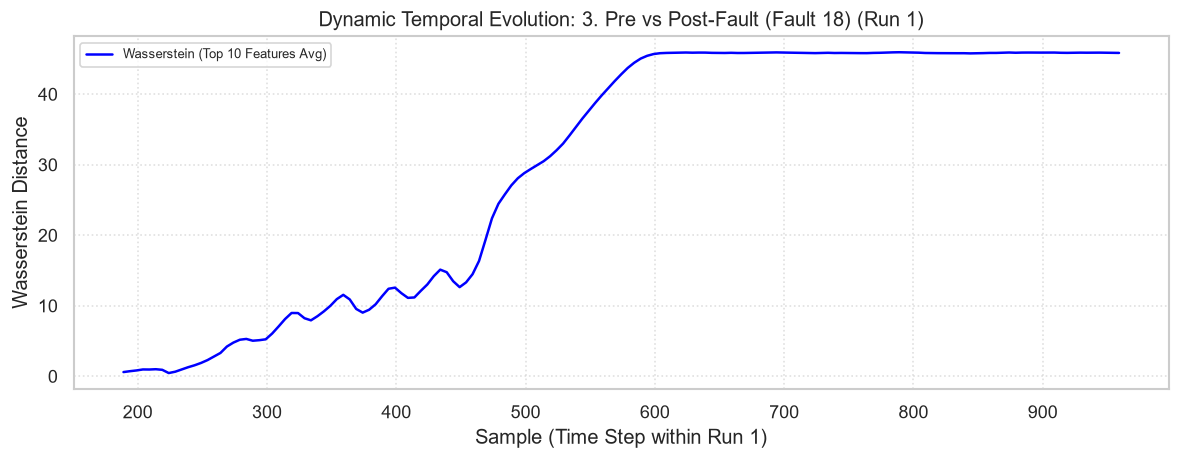

In [108]:
faults = [1, 2, 6, 18]

for i in faults:
    print(f"\nFault {i} pre vs post-fault analysis:\n")
    fault_i_run1 = df_faulty_test[(df_faulty_test['faultNumber'] == i) & (df_faulty_test['simulationRun'] == 1.0)]
    
    # Source: Finestra prima dell'iniezione del guasto (stato sano, es. campioni 100-150)
    source = fault_i_run1[(fault_i_run1['sample'] >= 100) & (fault_i_run1['sample'] < 160)]
    
    # Target: L'intera run o la parte successiva all'iniezione (stato guasto, es. campioni >= 160)
    target = fault_i_run1[fault_i_run1['sample'] >= 160]
    
    res_pre_post = evaluate_pair(
        df_source=source, 
        df_target=target, 
        features=features, 
        pair_name=f"3. Pre vs Post-Fault (Fault {i})", 
        top_n=10, 
        run_id=1.0, 
        injection_sample=160, # Qui la linea rossa a t=160 ha pienamente senso!
    )
    if res_pre_post: all_results.append(res_pre_post)

## Scenario 4: Stochastic Stability Check (Nominal Baseline Sanity Test)

### Methodology & Source-Target Selection:
* **Source (`source`)**: The first chronological half of the nominal testing dataset (`fault_free_test`).
* **Target (`target`)**: The second half of the same nominal testing dataset.
* **Interpretation**: This serves as a vital **sanity check**. Because both subsets originate from fault-free operations under normal stochastic variability, an ideal monitoring index should report near-zero discrepancy values and flat temporal profiles, proving that the method does not trigger false alarms during routine baseline shifts.

ANALYSIS SCENARIO: 4. Stochastic stability (Run 1 vs Run 50)
MMD Score (Global):        0.00223
Wasserstein (Average):     0.08278
Wasserstein (Max Feature): 0.18825
Mahalanobis (Covariance):  7.29


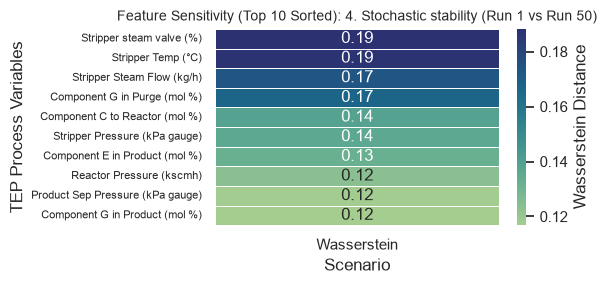

In [109]:
source = df_fault_free_test[df_fault_free_test['simulationRun'] == 1.0]
target = df_fault_free_test[df_fault_free_test['simulationRun'] == 50.0]

res3= evaluate_pair(source, target, features, 
              pair_name="4. Stochastic stability (Run 1 vs Run 50)", 
              injection_sample=0)
if res3: all_results.append(res3)

RIEPILOGO FINALE DEI RISULTATI

In [110]:
results_df = pd.DataFrame(all_results)
print("\nComparative Summary\n")
print(results_df.sort_values(by='Wasserstein_Avg', ascending=False).to_string(index=False))


Comparative Summary

                                 Scenario      MMD  Wasserstein_Avg  Mahalanobis
   2. Temporal Drift (Fault 18 Evolution) 0.027369        14.476466  2715.521260
           3. Pre vs Post-Fault (Fault 6) 0.021603        12.413581  4112.141909
                    1. Fault_0_vs_Fault_6 0.000695        11.000577   921.856228
          3. Pre vs Post-Fault (Fault 18) 0.030331        10.777927  1222.612654
                   1. Fault_0_vs_Fault_18 0.000664         8.815830   509.944346
    2. Temporal Drift (Fault 6 Evolution) 0.031098         7.132881  4536.413002
           3. Pre vs Post-Fault (Fault 2) 0.019793         3.623118   217.169589
    2. Temporal Drift (Fault 2 Evolution) 0.025352         3.305738   662.895390
                   1. Fault_0_vs_Fault_12 0.000678         2.990646    95.548083
                    1. Fault_0_vs_Fault_2 0.000818         2.851425    49.768946
                   1. Fault_0_vs_Fault_13 0.000683         2.380981    58.232921
      